# Some Common Derivatives — Higher Degree Polynomials

A guided notebook transcribed and expanded from the Coursera
*Calculus for Machine Learning and Data Science* lecture on the derivatives of
**cubics and higher polynomials** (Week 1 — Derivatives and Optimization).

This notebook explains:

- the cubic $f(x) = x^3$ and estimating its slope at $x = 0.5$ (slopes $\to 0.75$)
- the formal derivation $\dfrac{\Delta f}{\Delta x} = 3x^2 + 3x\,\Delta x + (\Delta x)^2 \to 3x^2$
- the result $\dfrac{d}{dx}x^3 = 3x^2$
- the general **power rule** $\dfrac{d}{dx}x^n = n\,x^{n-1}$, verified with SymPy

This notebook follows the repository `GUIDELINES.md` template and continues directly from
*Some Common Derivatives — Quadratics*.

## 1. The simplest cubic

After lines and quadratics, the next polynomial is the **cubic** $y = x^3$. As before, the
derivative is

$$
\frac{\Delta f}{\Delta x} = \frac{(x+\Delta x)^3 - x^3}{\Delta x},
\qquad \text{then } \Delta x \to 0 .
$$

## 2. Estimating the slope at $x = 0.5$

At $x = 0.5$, $y = (0.5)^3 = \tfrac18$. Let's shrink $\Delta x$ and watch the secant slope.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

def f(x):
    return x**3

x0 = 0.5
print(f"{'Δx':>10} | {'Δf':>10} | {'slope Δf/Δx':>12}")
print("-" * 38)
for dx in [1, 1/2, 1/4, 1/8, 1/16, 1/1000]:
    df = f(x0 + dx) - f(x0)
    print(f"{dx:>10.4f} | {df:>10.5f} | {df/dx:>12.5f}")
print("\n-> the slope approaches 0.75 = 3*(0.5)², the tangent slope at x=0.5.")

        Δx |         Δf |  slope Δf/Δx
--------------------------------------
    1.0000 |    3.25000 |      3.25000
    0.5000 |    0.87500 |      1.75000
    0.2500 |    0.29688 |      1.18750
    0.1250 |    0.11914 |      0.95312
    0.0625 |    0.05298 |      0.84766
    0.0010 |    0.00075 |      0.75150

-> the slope approaches 0.75 = 3*(0.5)², the tangent slope at x=0.5.


## 3. The formal derivation

Expand the cube $(x+\Delta x)^3 = x^3 + 3x^2\Delta x + 3x(\Delta x)^2 + (\Delta x)^3$:

$$
\frac{\Delta f}{\Delta x}
= \frac{x^3 + 3x^2\Delta x + 3x(\Delta x)^2 + (\Delta x)^3 - x^3}{\Delta x}.
$$

Cancel $x^3$ and divide each remaining term by $\Delta x$:

$$
\frac{\Delta f}{\Delta x} = 3x^2 + 3x\,\Delta x + (\Delta x)^2 .
$$

As $\Delta x \to 0$, every term with a $\Delta x$ vanishes:

$$
\boxed{\;\frac{d}{dx}\,x^3 = 3x^2.\;}
$$

In [2]:
x, dx = sp.symbols('x Delta_x')
ratio = ((x + dx)**3 - x**3) / dx
print("Δf/Δx =", sp.expand(ratio))                 # 3*x**2 + 3*x*Delta_x + Delta_x**2
print("limit Δx->0 =", sp.limit(ratio, dx, 0))     # 3*x**2
print("SymPy d/dx (x³) =", sp.diff(x**3, x))

Δf/Δx = Delta_x**2 + 3*Delta_x*x + 3*x**2
limit Δx->0 = 3*x**2
SymPy d/dx (x³) = 3*x**2


## 4. The power rule

Lines, quadratics, and cubics all fit one pattern — the **power rule**:

$$
\boxed{\;\frac{d}{dx}\,x^n = n\,x^{\,n-1}.\;}
$$

Check that it recovers everything so far:

| $f(x)$ | power rule $n x^{n-1}$ |
|---|---|
| $x^0 = 1$ (constant) | $0$ |
| $x^1$ (line) | $1$ |
| $x^2$ (quadratic) | $2x$ |
| $x^3$ (cubic) | $3x^2$ |
| $x^4$ | $4x^3$ |
| $x^5$ | $5x^4$ |

In [3]:
x = sp.symbols('x')
for n in range(6):
    print(f"d/dx x^{n} = {sp.diff(x**n, x)}")

d/dx x^0 = 0
d/dx x^1 = 1
d/dx x^2 = 2*x
d/dx x^3 = 3*x**2
d/dx x^4 = 4*x**3
d/dx x^5 = 5*x**4


### Polynomials term by term

A polynomial is differentiated term by term (each term by the power rule, constants times
the term's derivative).

In [4]:
for expr in [x**3, 2*x**3 - x**2 + 5*x - 7, x**5 + 3*x**4]:
    print(f"f(x) = {str(expr):>24}   ->   f'(x) = {sp.diff(expr, x)}")

f(x) =                     x**3   ->   f'(x) = 3*x**2
f(x) =  2*x**3 - x**2 + 5*x - 7   ->   f'(x) = 6*x**2 - 2*x + 5
f(x) =            x**5 + 3*x**4   ->   f'(x) = 5*x**4 + 12*x**3


## 5. Visualizing

**Left:** secants at $x=0.5$ on $y=x^3$ converging to the tangent of slope $0.75$.
**Right:** $f(x)=x^3$ and its derivative $f'(x)=3x^2$ (always $\ge 0$ — $x^3$ is
increasing).

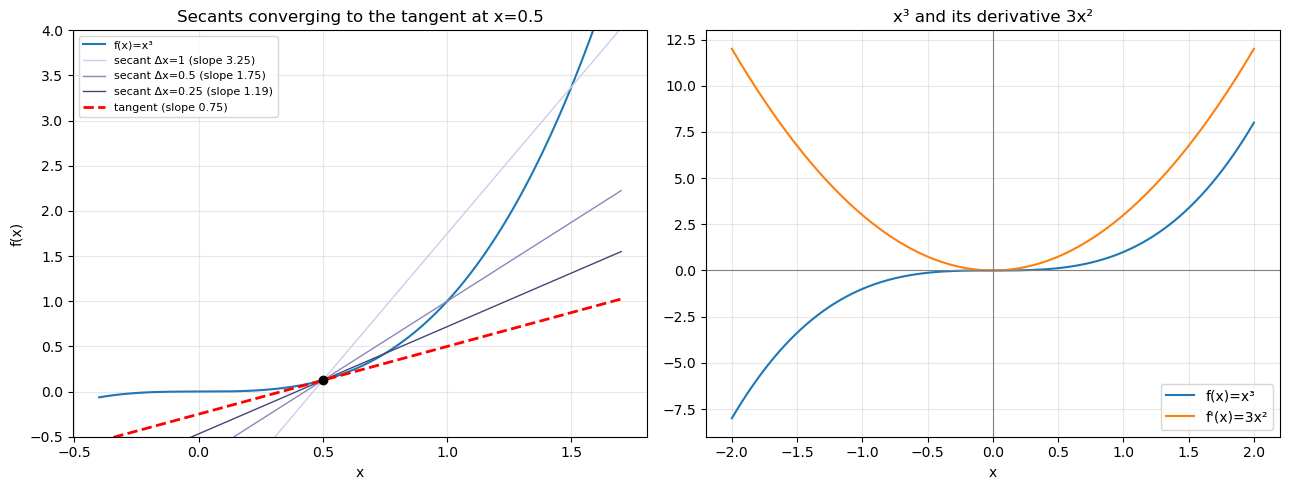

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

xs = np.linspace(-0.4, 1.7, 200)
axes[0].plot(xs, xs**3, label="f(x)=x³")
for dx, col in zip([1, 0.5, 0.25], ["#cce", "#88b", "#447"]):
    slope = ((0.5+dx)**3 - 0.5**3)/dx
    axes[0].plot(xs, 0.5**3 + slope*(xs-0.5), color=col, lw=1, label=f"secant Δx={dx} (slope {slope:.2f})")
axes[0].plot(xs, 0.125 + 0.75*(xs-0.5), "r--", lw=2, label="tangent (slope 0.75)")
axes[0].plot(0.5, 0.125, "ko")
axes[0].set_title("Secants converging to the tangent at x=0.5")
axes[0].set_xlabel("x"); axes[0].set_ylabel("f(x)")
axes[0].set_ylim(-0.5, 4); axes[0].grid(True, alpha=0.3); axes[0].legend(fontsize=8)

xs2 = np.linspace(-2, 2, 200)
axes[1].plot(xs2, xs2**3, label="f(x)=x³")
axes[1].plot(xs2, 3*xs2**2, label="f'(x)=3x²")
axes[1].axhline(0, color="gray", lw=0.8); axes[1].axvline(0, color="gray", lw=0.8)
axes[1].set_title("x³ and its derivative 3x²")
axes[1].set_xlabel("x"); axes[1].grid(True, alpha=0.3); axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Exercises

### Basic
1. What is the derivative of $f(x) = x^3$?
2. State the power rule.

### Intermediate
3. Estimate the slope of $x^3$ at $x = 2$ numerically and compare to $3x^2$.
4. Differentiate $f(x) = x^5 - 2x^3 + 4x$.

### Advanced
5. Using the limit definition, derive $\dfrac{d}{dx}x^3$.
6. Use the power rule to differentiate $f(x) = x^{10}$ and $g(x) = x^{1/2} = \sqrt{x}$.

## 7. Solutions / Checks

In [6]:
x = sp.symbols('x')

# 3.
dx = 1e-6
print(f"3. numeric slope of x³ at 2: {((2+dx)**3 - 2**3)/dx:.4f}  (exact 3*4=12)")

# 4.
print("4. d/dx (x⁵-2x³+4x) =", sp.diff(x**5 - 2*x**3 + 4*x, x))

# 5.
h = sp.symbols('h')
print("5. limit definition d/dx x³ =", sp.simplify(sp.limit(((x+h)**3 - x**3)/h, h, 0)))

# 6.
print("6. d/dx x^10 =", sp.diff(x**10, x), ";  d/dx sqrt(x) =", sp.diff(x**sp.Rational(1,2), x))

print("\n1. 3x².")
print("2. d/dx xⁿ = n x^(n-1).")

3. numeric slope of x³ at 2: 12.0000  (exact 3*4=12)
4. d/dx (x⁵-2x³+4x) = 5*x**4 - 6*x**2 + 4


5. limit definition d/dx x³ = 3*x**2
6. d/dx x^10 = 10*x**9 ;  d/dx sqrt(x) = 1/(2*sqrt(x))

1. 3x².
2. d/dx xⁿ = n x^(n-1).


## 8. Conclusion

- For the cubic $f(x) = x^3$, shrinking $\Delta x$ at $x = 0.5$ gives slopes converging to
  $0.75 = 3(0.5)^2$.
- Formally $\dfrac{\Delta f}{\Delta x} = 3x^2 + 3x\,\Delta x + (\Delta x)^2 \to 3x^2$, so
  $\dfrac{d}{dx}x^3 = 3x^2$.
- This is one case of the **power rule** $\dfrac{d}{dx}x^n = n\,x^{n-1}$, which also covers
  constants, lines, and quadratics, and lets us differentiate any polynomial term by term.
- Next come other power functions, exponentials, logarithms, and trigonometric functions.

## Appendix — Source transcript

Transcribed with OpenAI Whisper (`small.en`) from a locally downloaded video
(`~/Downloads/index (9).mp4`), the Coursera *Calculus for Machine Learning and Data
Science* (Week 1) lecture **some common derivatives — higher degree polynomials**. Key
spoken points, lightly cleaned:

> The simplest cubic is $y = x^3$. The derivative is $((x+\Delta x)^3 - x^3)/\Delta x$ as
> $\Delta x \to 0$. At $x = 0.5$ ($y = 1/8$): $\Delta x = 1$ gives the point $(3/2, 27/8)$,
> $\Delta f = 27/8 - 1/8 = 3.25$, slope $3.25$; $\Delta x = 1/2$ gives $\Delta f = 7/8
> \approx 0.86$, slope $1.75$; $\Delta x = 1/4$ gives slope $1.188$; $1/8$ gives $0.95$;
> $1/16$ gives $0.85$; $1/1000$ gives $0.752$ — converging to $0.75 = 3\times(0.5)^2$. So
> $f'(0.5) = 0.75$. Formally, expanding the cube and cancelling, $\Delta f/\Delta x = 3x^2 +
> 3x\,\Delta x + (\Delta x)^2$, and as $\Delta x \to 0$ only $3x^2$ remains. So for $f(x) =
> x^3$, $f'(x) = 3x^2$.